In [1]:
import wmpaws
import pandas as pd

In [2]:
query = """
SELECT 
    ug_user,
    ug_group
FROM 
    user_groups
WHERE 
    ug_group IN ('sysop', 'bureaucrat', 'checkuser', 'oversight', 'rollbacker', 'steward')
"""

In [3]:
wikis = ['pawiki', 'hiwiki', 'aswiki', 'mlwiki', 'bhwiki', 'mrwiki', 'knwiki',
         'tawiki', 'sawiki', 'tewiki', 'bnwiki', 'guwiki', 'satwiki', 'awawiki']

In [4]:
df_list = []
for wiki in wikis:
    try:
        wiki_df = wmpaws.run_sql(query, wiki)
        wiki_df['wiki'] = wiki
        df_list.append(wiki_df)
    except Exception as e:
        print(f"Failed on {wiki}: {e}")

rights_df = pd.concat(df_list, ignore_index=True)
rights_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 335 entries, 0 to 334
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   ug_user   335 non-null    int64
 1   ug_group  335 non-null    str  
 2   wiki      335 non-null    str  
dtypes: int64(1), str(2)
memory usage: 12.7 KB


In [5]:
users_per_wiki = rights_df.groupby('wiki')['ug_user'].nunique()
users_per_wiki

wiki
aswiki      6
awawiki     2
bhwiki      2
bnwiki     96
guwiki      7
hiwiki     28
knwiki      4
mlwiki     85
mrwiki     17
pawiki     10
satwiki     2
sawiki      3
tawiki     41
tewiki     11
Name: ug_user, dtype: int64

In [6]:
role_breakdown = rights_df.groupby(['wiki', 'ug_group']).size().reset_index(name='count')
role_breakdown

,wiki,ug_group,count
0,aswiki,sysop,6
1,awawiki,sysop,2
2,bhwiki,sysop,2
3,bnwiki,bureaucrat,2
4,bnwiki,checkuser,3
5,bnwiki,rollbacker,80
6,bnwiki,sysop,16
7,guwiki,rollbacker,5
8,guwiki,sysop,3
9,hiwiki,rollbacker,21


In [7]:
overlap_matrix = pd.crosstab(rights_df['ug_user'], rights_df['ug_group'])
overlap_matrix.head(10)

ug_group,bureaucrat,checkuser,rollbacker,sysop
ug_user,,,,
3,0,0,0,1
5,1,0,0,1
40,0,0,0,1
52,1,0,0,1
64,0,0,1,0
65,0,0,0,1
79,0,0,0,1
102,1,0,0,1
154,0,0,1,0


In [8]:
overlap_matrix['num_rights_held'] = overlap_matrix.sum(axis=1)
overlap_matrix['num_rights_held'].value_counts().sort_index()

num_rights_held
1    294
2     19
3      1
Name: count, dtype: int64

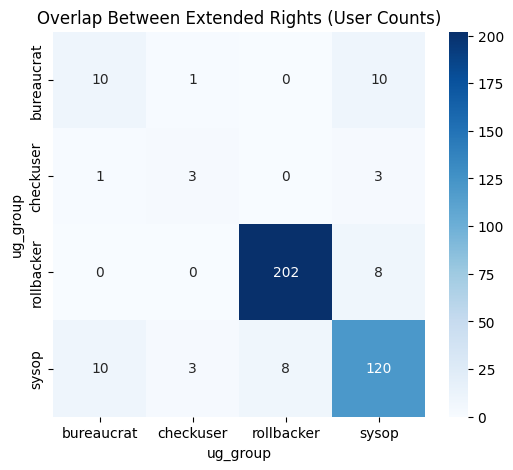

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

co_occurrence = overlap_matrix.drop(columns='num_rights_held').T.dot(
    overlap_matrix.drop(columns='num_rights_held')
)

plt.figure(figsize=(6,5))
sns.heatmap(co_occurrence, annot=True, fmt='d', cmap='Blues')
plt.title('Overlap Between Extended Rights (User Counts)')
plt.show()

In [10]:
priority = {'steward': 1, 'oversight': 2, 'checkuser': 3, 'bureaucrat': 4, 'sysop': 5, 'rollbacker': 6}
rights_df['priority'] = rights_df['ug_group'].map(priority)

primary_rights_df = rights_df.sort_values('priority').drop_duplicates(subset=['ug_user', 'wiki'], keep='first')
primary_rights_df['ug_group'].value_counts()

ug_group
rollbacker    194
sysop         108
bureaucrat      9
checkuser       3
Name: count, dtype: int64

In [11]:
gender_query = """
SELECT 
    up_user AS ug_user,
    up_value AS gender
FROM user_properties
WHERE up_property = 'gender'
"""

gender_list = []
for wiki in wikis:
    try:
        g_df = wmpaws.run_sql(gender_query, wiki)
        g_df['wiki'] = wiki
        gender_list.append(g_df)
    except Exception as e:
        print(f"Failed on {wiki}: {e}")

gender_df = pd.concat(gender_list, ignore_index=True)
gender_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30429 entries, 0 to 30428
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   ug_user  30429 non-null  int64
 1   gender   30429 non-null  str  
 2   wiki     30429 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1020.2 KB


In [12]:
rights_gender_df = primary_rights_df.merge(gender_df, on=['ug_user', 'wiki'], how='left')
rights_gender_df['gender'] = rights_gender_df['gender'].fillna('unspecified')
rights_gender_df[['ug_user', 'ug_group', 'wiki', 'gender']].head(10)

,ug_user,ug_group,wiki,gender
0,157985,checkuser,bnwiki,male
1,42623,checkuser,bnwiki,male
2,154396,checkuser,bnwiki,male
3,2379,bureaucrat,tewiki,male
4,22471,bureaucrat,mlwiki,male
5,10521,bureaucrat,mlwiki,unspecified
6,6636,bureaucrat,bnwiki,male
7,3079,bureaucrat,tewiki,male
8,206,bureaucrat,mrwiki,unspecified
9,102,bureaucrat,tawiki,male


In [13]:
gender_by_wiki = rights_gender_df.groupby(['wiki', 'gender']).size().reset_index(name='count')
gender_by_wiki

,wiki,gender,count
0,aswiki,male,3
1,aswiki,unspecified,3
2,awawiki,unspecified,2
3,bhwiki,unspecified,2
4,bnwiki,female,1
5,bnwiki,male,66
6,bnwiki,unspecified,29
7,guwiki,male,5
8,guwiki,unspecified,2
9,hiwiki,male,12


In [14]:
gender_by_right = rights_gender_df.groupby(['ug_group', 'gender']).size().reset_index(name='count')
gender_by_right

,ug_group,gender,count
0,bureaucrat,male,6
1,bureaucrat,unspecified,3
2,checkuser,male,3
3,rollbacker,female,5
4,rollbacker,male,128
5,rollbacker,unspecified,61
6,sysop,female,4
7,sysop,male,67
8,sysop,unspecified,37


In [15]:
print(rights_gender_df['gender'].value_counts(dropna=False))
print(f"\nDisclosure rate: {(rights_gender_df['gender'] != 'unspecified').mean():.1%}")

gender
male           204
unspecified    101
female           9
Name: count, dtype: int64

Disclosure rate: 67.8%
